In [5]:
import hydra
import argparse
from omegaconf import DictConfig, OmegaConf
import matplotlib.pyplot as plt
import numpy as np
import torch
import logging
import os


In [7]:

ckpt_dir = "outputs/letters_coupled_exp_bcdf36dc71e6831a478a935d8c7a2b01"

# Resolve and validate checkpoint directory
experiment_dir = os.path.abspath(os.path.expanduser(str(ckpt_dir)))
cfg_path = os.path.join(experiment_dir, 'config.yaml')
ckpt_path = os.path.join(experiment_dir, 'best_model.pt')

# Load trained config and use it as the active config
trained_cfg = OmegaConf.load(cfg_path)

# Set random seed for reproducibility
if OmegaConf.select(trained_cfg, 'seed') is not None:
    torch.manual_seed(trained_cfg.seed)
    np.random.seed(trained_cfg.seed)

dataset = hydra.utils.instantiate(trained_cfg.dataset)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)



cpu


!!!!!! (100, 2)
!!!!!! (100, 2)
!!!!!! (100, 2)
!!!!!! (100, 2)
!!!!!! (100, 2)
!!!!!! (100, 2)


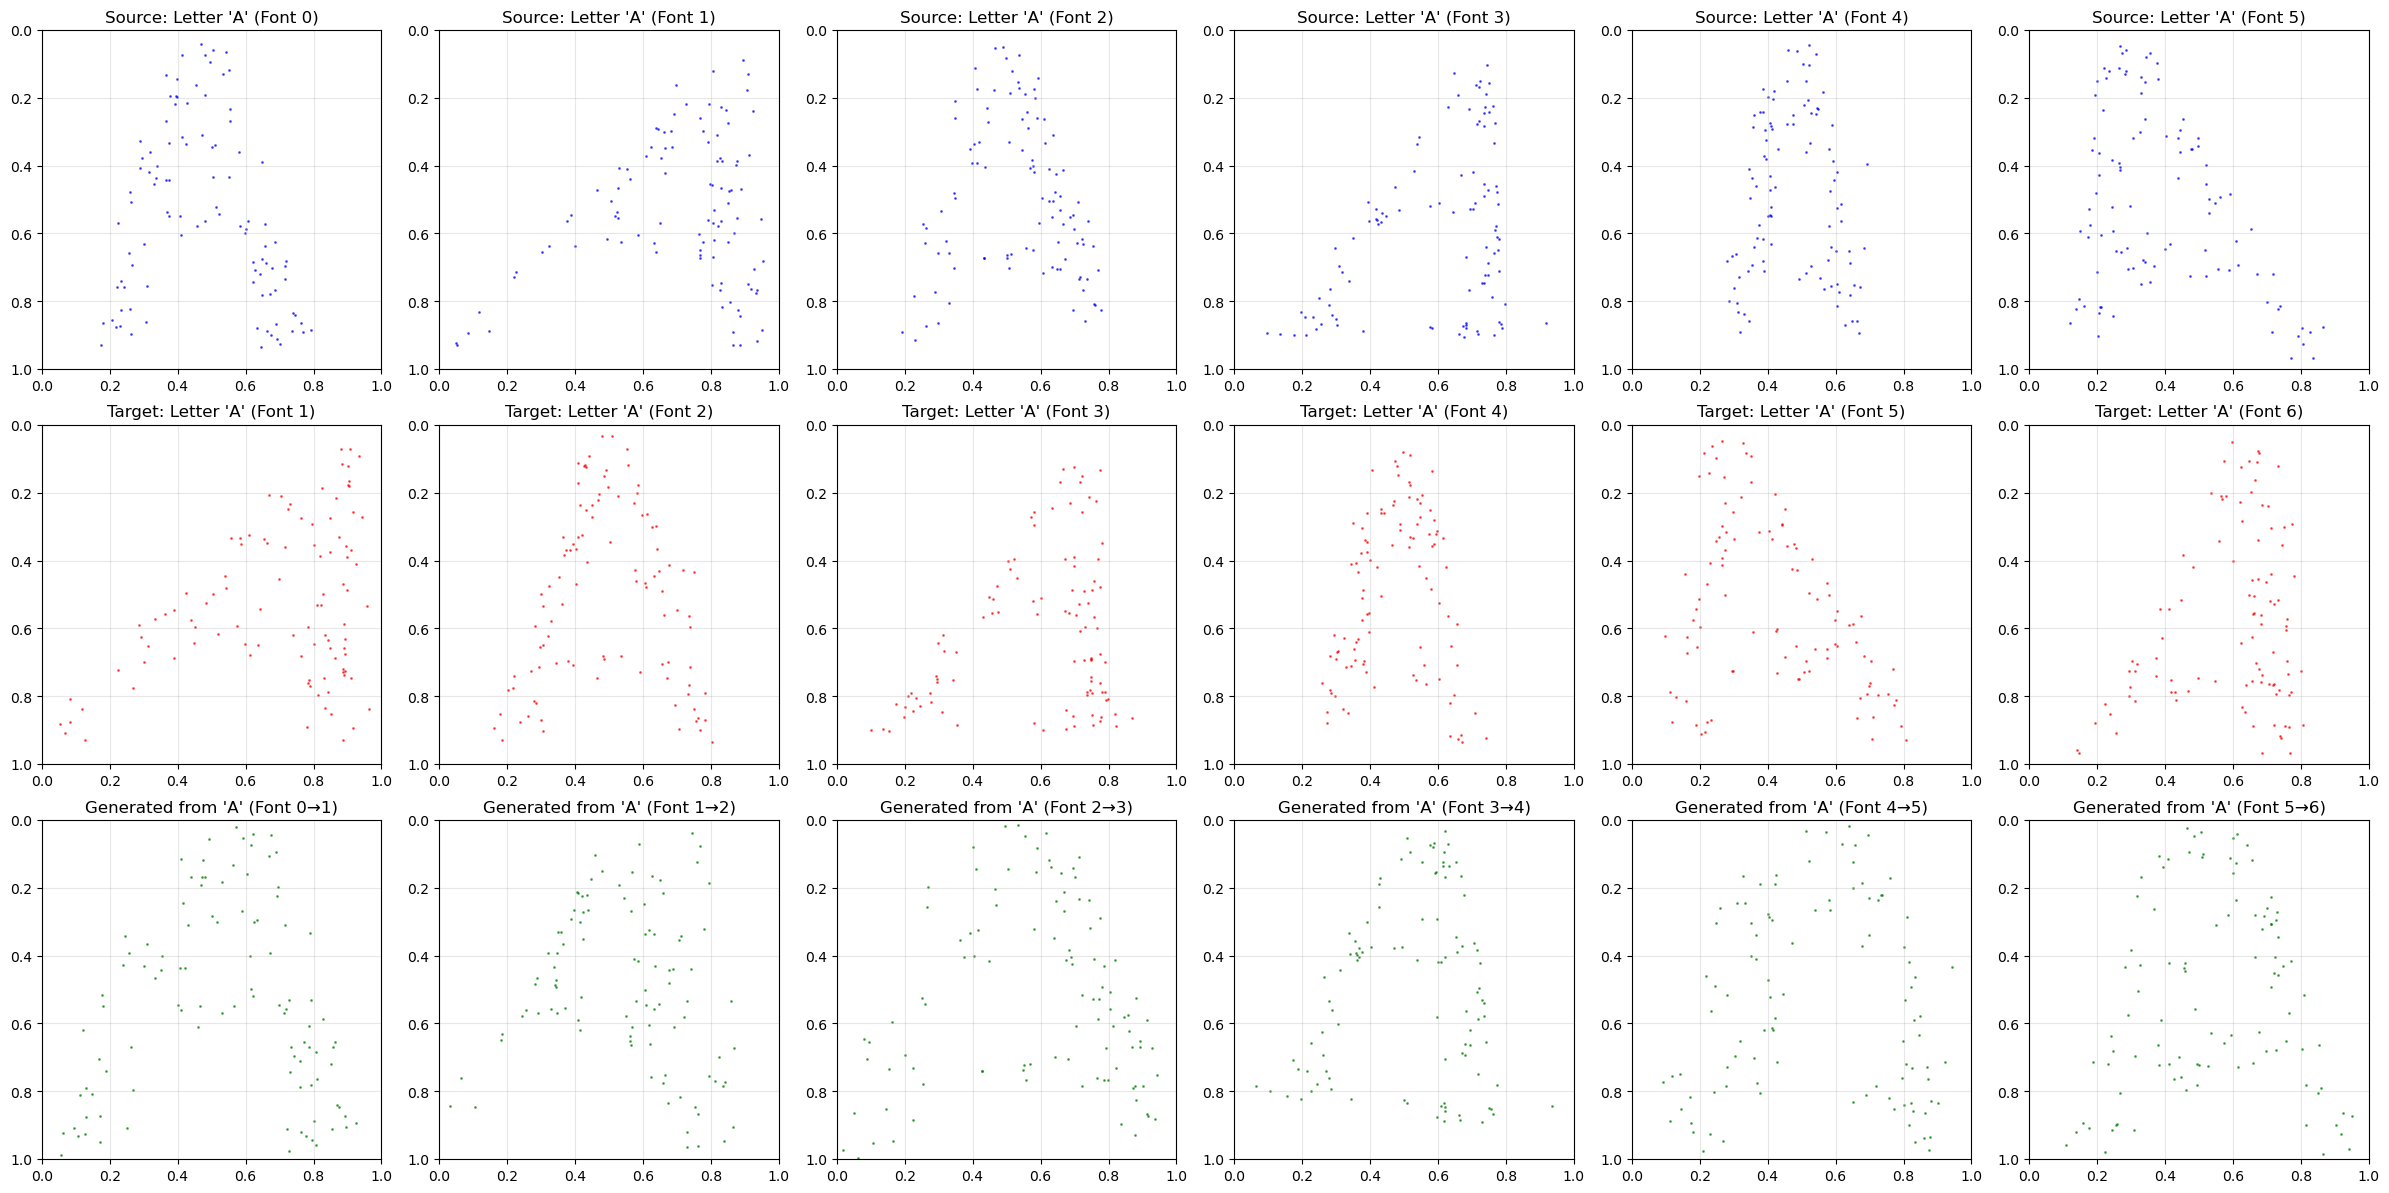

In [10]:

encoder = hydra.utils.instantiate(trained_cfg.encoder).to(device)
generator = hydra.utils.instantiate(trained_cfg.generator).to(device)

checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)

encoder.load_state_dict(checkpoint['encoder_state_dict'])
generator.load_state_dict(checkpoint['generator_state_dict'])
encoder.eval()
generator.eval()


num_examples = min(6, len(dataset))  # Show up to 6 examples

num_rows = 3
fig_height = 12
fig, axes = plt.subplots(num_rows, num_examples, figsize=(4*num_examples, fig_height))
if num_examples == 1:
    axes = axes.reshape(num_rows, 1)

    
for i in range(num_examples):
    # Get dataset item
    item = dataset[i]
    source_samples = item['source_samples']
    target_samples = item['target_samples']
    
    # Determine which letter and fonts we're looking at
    letter = dataset.train_letters[i // (dataset.num_fonts - 1)]
    font = i % (dataset.num_fonts - 1)
    
    # Plot source samples
    axes[0, i].scatter(source_samples[:, 0], source_samples[:, 1], 
                    alpha=0.6, s=1, c='blue')
    axes[0, i].set_title(f"Source: Letter '{letter}' (Font {font})")
    axes[0, i].set_xlim(0, 1)
    axes[0, i].set_ylim(0, 1)
    axes[0, i].set_aspect('equal')
    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].invert_yaxis()  # Invert y-axis to match image coordinates
    
    # Plot target samples  
    axes[1, i].scatter(target_samples[:, 0], target_samples[:, 1], 
                    alpha=0.6, s=1, c='red')
    axes[1, i].set_title(f"Target: Letter '{letter}' (Font {font+1})")
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_ylim(0, 1)
    axes[1, i].set_aspect('equal')
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].invert_yaxis()  # Invert y-axis to match image coordinates
    

    with torch.no_grad():
        # Prepare tensors
        src_tensor = source_samples.to(device)
        tgt_tensor = target_samples.to(device)
        # Encode to latents (batch with single set)
        src_latent = encoder(src_tensor.unsqueeze(0))  # [1, latent_dim]
        tgt_latent = None #encoder(tgt_tensor.unsqueeze(0))  # [1, latent_dim]
        # Generate from source samples conditioned on src/target latents
        gen = generator.sample(src_tensor, src_latent, tgt_latent)  # [1, set_size, 2]
        gen_np = gen.squeeze(0).detach().cpu().numpy()
    print("!!!!!!", gen_np.shape)
    axes[2, i].scatter(gen_np[:, 0], gen_np[:, 1], alpha=0.6, s=1, c='green')
    axes[2, i].set_title(f"Generated from '{letter}' (Font {font}→{font+1})")
    axes[2, i].set_xlim(0, 1)
    axes[2, i].set_ylim(0, 1)
    axes[2, i].set_aspect('equal')
    axes[2, i].grid(True, alpha=0.3)
    axes[2, i].invert_yaxis()

plt.tight_layout() 

plt.show()


